###Understanding the data

In [25]:
#importing necessary packages
import pandas as pd
from matplotlib.pyplot import xlabel
from sklearn.datasets import fetch_openml
import seaborn as sns
import matplotlib.pyplot as plt

We start by fetching the data from openml and check their structure.

In [3]:
#load data from csv
freq = fetch_openml(data_id=41214, as_frame=True).data
sev = fetch_openml(data_id=41215, as_frame=True).data

print(freq.info())
print(sev.info())

<class 'pandas.DataFrame'>
RangeIndex: 678013 entries, 0 to 678012
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   IDpol       678013 non-null  float64 
 1   ClaimNb     678013 non-null  int64   
 2   Exposure    678013 non-null  float64 
 3   Area        678013 non-null  category
 4   VehPower    678013 non-null  int64   
 5   VehAge      678013 non-null  int64   
 6   DrivAge     678013 non-null  int64   
 7   BonusMalus  678013 non-null  int64   
 8   VehBrand    678013 non-null  category
 9   VehGas      678013 non-null  str     
 10  Density     678013 non-null  int64   
 11  Region      678013 non-null  category
dtypes: category(3), float64(2), int64(6), str(1)
memory usage: 48.5 MB
None
<class 'pandas.DataFrame'>
RangeIndex: 26639 entries, 0 to 26638
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   IDpol        26639 non-null  int64 

The *freq* dataset contains 678,013 entries with 12 features including policy ID *IDpol* and frequency *ClaimNb*.
The *sev* dataset contains 26,639 entries with 2 features *IDpol* and Severity *ClaimAmount*.
We note that the number of entries of the two datasets differs vastly. This however is to be expected, since most policies will not have a claim.
Before merging the dataframes, we check for potential duplicates.

In [4]:
print(f'{freq.duplicated(subset='IDpol').sum()} duplicates in IDpol column of freq DataFrame')
print(f'{sev.duplicated(subset='IDpol').sum()} duplicates in IDpol column of sev DataFrame')
print(f'{(freq['ClaimNb']>1).sum()} IDs with multiple claims in freq dataset')

0 duplicates in IDpol column of freq DataFrame
1689 duplicates in IDpol column of sev DataFrame
1882 IDs with multiple claims in freq dataset


Considering the policy ID, there are 0 duplicates in the frequency dataset. However, there are 1689 duplicates in the severity dataset, which is most likely due to multiple claims per policy. Still, this is not a one-to-one relation as there are more IDs with multiple claims in the frequency data than duplicates in the severity data.
Before moving on we aggregate the sev dataframe, resulting in unique identifiers.

In [5]:
#sum ClaimAmount over IDs
sev_agg = sev.groupby('IDpol').agg(ClaimAmount=('ClaimAmount','sum')).reset_index()

In [6]:
print(f'Number of IDs included in sev data but no in freq: {sev_agg[~sev_agg['IDpol'].isin(freq['IDpol'])].shape[0]}')

Number of IDs included in sev data but no in freq: 6


There are 6 rows in the sev data not included in the freq data. We will drop these using a left-join.

In [29]:
#merge data into one df, using left-join, so only IDs having features are used
df = pd.merge(freq,sev_agg,on='IDpol',how='left',validate='one_to_one')
df.set_index('IDpol',inplace=True)

#fill rows with no ClaimAmount with 0
df['ClaimAmount'] = df['ClaimAmount'].fillna(0)

The dataframes where merged successfully with a one-to-one relation.

Let's now have a look at the data.

In [11]:
df.head()

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,ClaimAmount
0,1.0,1,0.10,D,5,0,55,50,B12,'Regular',1217,R82,0.0
1,3.0,1,0.77,D,5,0,55,50,B12,'Regular',1217,R82,0.0
2,5.0,1,0.75,B,6,2,52,50,B12,'Diesel',54,R22,0.0
3,10.0,1,0.09,B,7,0,46,50,B12,'Diesel',76,R72,0.0
4,11.0,1,0.84,B,7,0,46,50,B12,'Diesel',76,R72,0.0


In [10]:
df.describe(include='all')

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,ClaimAmount
count,6.780130e+05,678013.000000,678013.000000,678013,678013.000000,678013.000000,678013.000000,678013.000000,678013,678013,678013.000000,678013,6.780130e+05
unique,NaN,NaN,NaN,6,NaN,NaN,NaN,NaN,11,2,NaN,22,NaN
top,NaN,NaN,NaN,C,NaN,NaN,NaN,NaN,B12,'Regular',NaN,R24,NaN
freq,NaN,NaN,NaN,191880,NaN,NaN,NaN,NaN,166024,345877,NaN,160601,NaN
mean,2.621857e+06,0.053247,0.528750,NaN,6.454631,7.044265,45.499122,59.761502,NaN,NaN,1792.422405,NaN,8.835998e+01
std,1.641783e+06,0.240117,0.364442,NaN,2.050906,5.666232,14.137444,15.636658,NaN,NaN,3958.646564,NaN,5.822454e+03
min,1.000000e+00,0.000000,0.002732,NaN,4.000000,0.000000,18.000000,50.000000,NaN,NaN,1.000000,NaN,0.000000e+00
25%,1.157951e+06,0.000000,0.180000,NaN,5.000000,2.000000,34.000000,50.000000,NaN,NaN,92.000000,NaN,0.000000e+00
50%,2.272152e+06,0.000000,0.490000,NaN,6.000000,6.000000,44.000000,50.000000,NaN,NaN,393.000000,NaN,0.000000e+00
75%,4.046274e+06,0.000000,0.990000,NaN,7.000000,11.000000,55.000000,64.000000,NaN,NaN,1658.000000,NaN,0.000000e+00


At first glance the data quality seems good.

We will take a look at the categorical columns next, confirming if there is any preprocessing to do. Before we transform the VehGas column to categorical.

In [22]:
df['VehGas'] = df['VehGas'].str.replace("'","").astype('category')

In [23]:
for col in df.select_dtypes('category').columns:
    print(f'{col} Value Counts:\n {df[col].value_counts(dropna=False)}')

Area Value Counts:
 Area
C    191880
D    151596
E    137167
A    103957
B     75459
F     17954
Name: count, dtype: int64
VehBrand Value Counts:
 VehBrand
B12    166024
B1     162736
B2     159861
B3      53395
B5      34753
B6      28548
B4      25179
B10     17707
B11     13585
B13     12178
B14      4047
Name: count, dtype: int64
VehGas Value Counts:
 VehGas
Regular    345877
Diesel     332136
Name: count, dtype: int64
Region Value Counts:
 Region
R24    160601
R82     84752
R93     79315
R11     69791
R53     42122
R52     38751
R91     35805
R72     31329
R31     27285
R54     19046
R73     17141
R41     12990
R25     10893
R26     10492
R23      8784
R22      7994
R83      5287
R74      4567
R94      4516
R21      3026
R42      2200
R43      1326
Name: count, dtype: int64


There are no irregularities in these columns.

We now turn to the numerical columns.

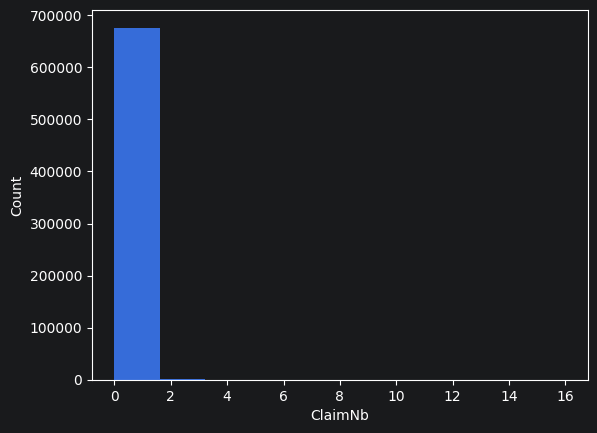

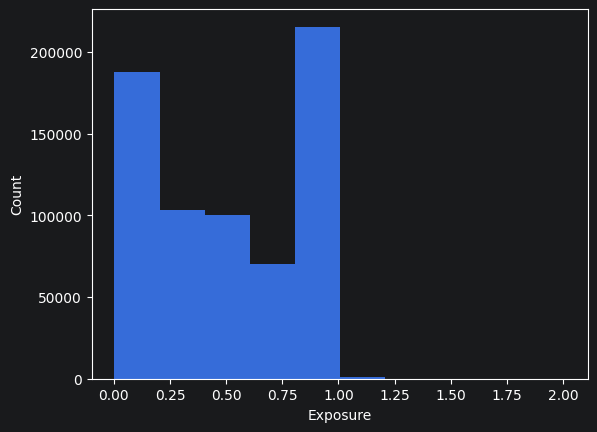

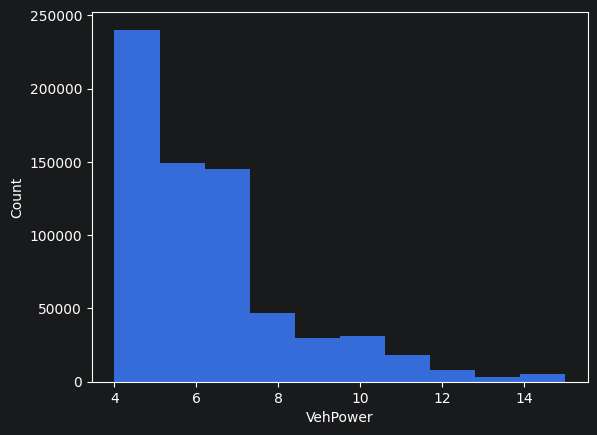

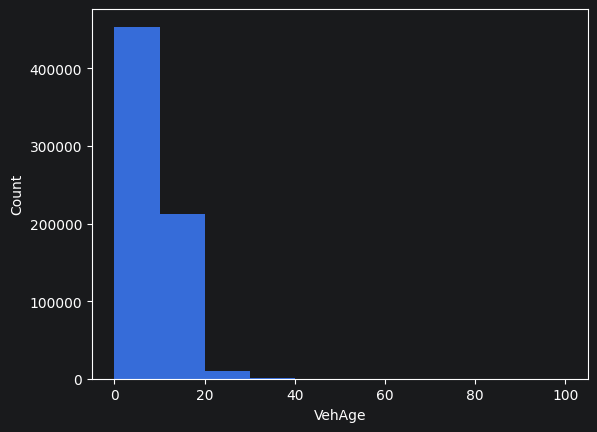

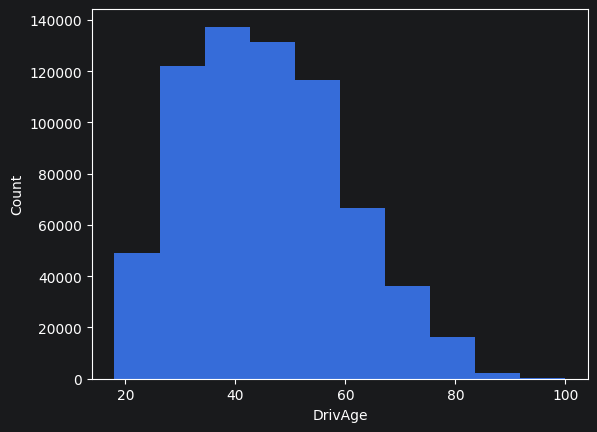

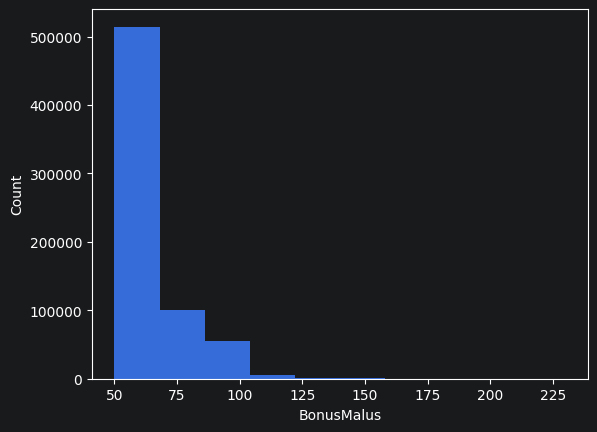

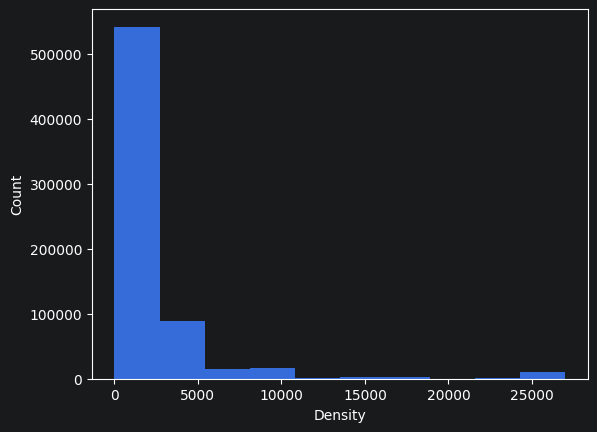

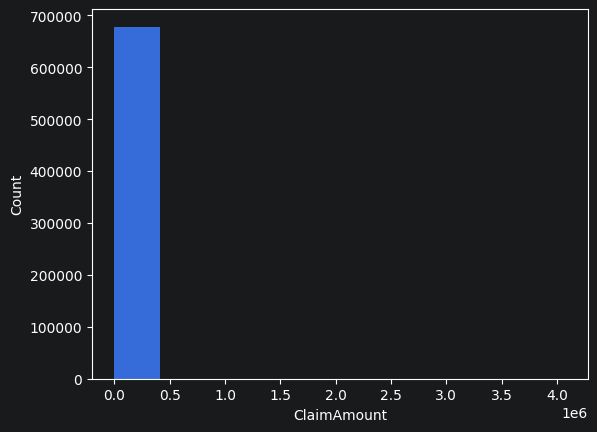

In [38]:
for col in df.select_dtypes('number').columns:
    plt.hist(df[col])
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()